In [ ]:
import warnings, time
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=UserWarning, module='statsmodels')
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set(style="whitegrid")
from pathlib import Path


from pmdarima import auto_arima
from pmdarima.arima import ndiffs, nsdiffs

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera


from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler




In [ ]:
!git clone https://github.com/HoangHumg1210/hoankiem-air-quality-.git
%cd hoankiem-air-quality-

Cloning into 'hoankiem-air-quality-'...
remote: Enumerating objects: 42, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 42 (delta 9), reused 40 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (42/42), 7.08 MiB | 25.53 MiB/s, done.
Resolving deltas: 100% (9/9), done.
/content/hoankiem-air-quality-


In [ ]:
TARGET = "PM25"
DATA_PATH = "data/processed/data2225_done.csv"
TRAIN_END = "2023-12-31 23:00:00"
VAL_END = "2024-12-31 23:00:00"



In [ ]:
df = pd.read_csv(DATA_PATH)
df["Local Time"] = pd.to_datetime(df["Local Time"])
df = df.sort_values("Local Time").set_index("Local Time")

# Chuan hoa tan suat 1h
df = df[~df.index.duplicated(keep="last")]
df = df.asfreq("1h")

# Fill bien loai
df["HolidayName"] = df["HolidayName"].ffill().bfill().fillna("Unknown")
df["IsHoliday"] = (
    df["IsHoliday"]
    .replace({True: 1, False: 0, "True": 1, "False": 0})
    .ffill()
    .bfill()
    .astype(int)
)

# Fill bien so
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].interpolate(method="time").ffill().bfill()

# Time features
idx = df.index
df["hour_sin"] = np.sin(2 * np.pi * idx.hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * idx.hour / 24)
df["dow_sin"] = np.sin(2 * np.pi * idx.dayofweek / 7)
df["dow_cos"] = np.cos(2 * np.pi * idx.dayofweek / 7)

# One-hot holiday
df = pd.get_dummies(df, columns=["HolidayName"], drop_first=True)

feature_cols = [c for c in df.columns if c != TARGET]
df[feature_cols] = (
    df[feature_cols]
    .apply(pd.to_numeric, errors="coerce")
    .ffill()
    .bfill()
    .astype(float)
)

print(df.shape)
df.head()


(34769, 36)


,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,...,HolidayName_Lễ Giỗ Tổ 2022,HolidayName_Lễ Giỗ Tổ 2024,HolidayName_Lễ Giỗ Tổ 2025,HolidayName_Ngày thường,HolidayName_Tết 2022,HolidayName_Tết 2023,HolidayName_Tết 2024,HolidayName_Tết 2025,HolidayName_Tết Dương 2023,HolidayName_Tết Dương 2024
Local Time,,,,,,,,,,,,,,,,,,,,,
2022-01-13 07:00:00,353.1,10.0,84.0,98.0,17.08,52.0,100.0,0.00,1020.0,95.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-01-13 08:00:00,343.5,9.0,87.3,95.7,16.75,48.7,91.0,0.00,1021.0,94.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-01-13 09:00:00,334.0,8.0,90.7,93.3,16.42,45.3,83.0,0.50,1022.0,93.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-01-13 10:00:00,324.5,7.0,94.0,91.0,16.09,42.0,75.0,0.75,1022.0,93.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-01-13 11:00:00,319.6,6.7,95.7,91.3,16.17,39.0,83.0,0.00,1021.0,87.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
train_df = df.loc[:TRAIN_END].copy()
val_df = df.loc["2024-01-01":VAL_END].copy()
test_df = df.loc["2025-01-01":].copy()

print("train:", train_df.index.min(), "->", train_df.index.max(), "|", train_df.shape)
print("val  :", val_df.index.min(), "->", val_df.index.max(), "|", val_df.shape)
print("test :", test_df.index.min(), "->", test_df.index.max(), "|", test_df.shape)

y_train = train_df[TARGET]
y_val = val_df[TARGET]
y_test = test_df[TARGET]

# exog_train = train_df[feature_cols]
# exog_val = val_df[feature_cols]
# exog_test = test_df[feature_cols]


train: 2022-01-13 07:00:00 -> 2023-12-31 23:00:00 | (17225, 36)
val  : 2024-01-01 00:00:00 -> 2024-12-31 23:00:00 | (8784, 36)
test : 2025-01-01 00:00:00 -> 2025-12-31 23:00:00 | (8760, 36)


Kiểm định ADF/KPSS trên y_train:
ADF statistic: -6.4487 | p-value: 0.0000
Critical Values: {'1%': np.float64(-3.430730691346652), '5%': np.float64(-2.861708250674332), '10%': np.float64(-2.566859555500819)}
=> stationary (không cần sai phân)
KPSS statistic: 4.6846 | p-value: 0.0100
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
=> non-stationary (reject H0)
pmdarima gợi ý: d = 0 , D = 0 (m=7)


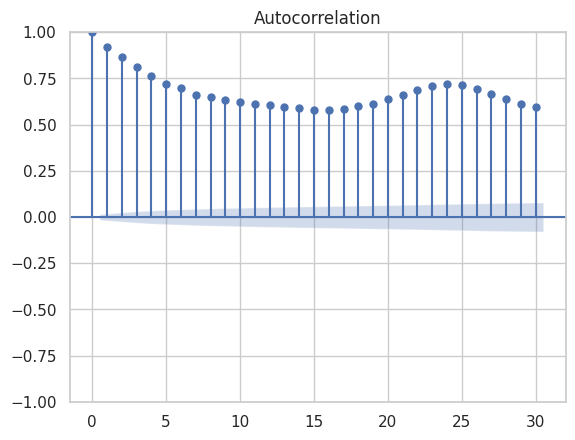

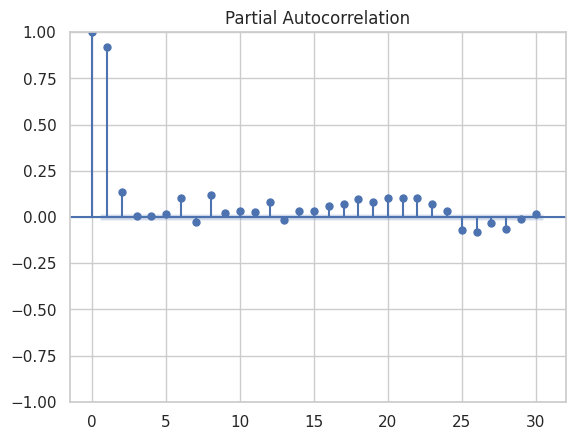

In [ ]:
# Kiểm định ADF/KPSS -> tính dừng
def adf_test(series):
    res = adfuller(series.dropna(), autolag='AIC')
    print("ADF statistic: %.4f | p-value: %.4f" % (res[0], res[1]))
    print("Critical Values:", res[4])
    print("=>", "stationary (không cần sai phân)" if res[1]<0.05 else "non-stationary (cần sai phân)")

def kpss_test(series):
    res = kpss(series.dropna(), regression='c', nlags='auto')
    print("KPSS statistic: %.4f | p-value: %.4f" % (res[0], res[1]))
    print("Critical Values:", res[3])
    print("=>", "non-stationary (reject H0)" if res[1]<0.05 else "stationary (không reject H0)")

# Dùng y_train để kiểm định
print("Kiểm định ADF/KPSS trên y_train:")
adf_test(y_train)
kpss_test(y_train)

# pmdarima gợi ý d và D
d_suggest = ndiffs(y_train, test='adf')
D_suggest = nsdiffs(y_train, m=7, test='ch')
print("pmdarima gợi ý: d =", d_suggest, ", D =", D_suggest, "(m=7)")


plot_acf(y_train.dropna(), lags=30)
plt.show()
plot_pacf(y_train.dropna(), lags=30, method='ywm')
plt.show()

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34769 entries, 2022-01-13 07:00:00 to 2025-12-31 23:00:00
Freq: h
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   CO                            34769 non-null  float64
 1   NO2                           34769 non-null  float64
 2   O3                            34769 non-null  float64
 3   PM10                          34769 non-null  float64
 4   PM25                          34769 non-null  float64
 5   SO2                           34769 non-null  float64
 6   Clouds                        34769 non-null  float64
 7   Precipitation                 34769 non-null  float64
 8   Pressure                      34769 non-null  float64
 9   Relative Humidity             34769 non-null  float64
 10  Temperature                   34769 non-null  float64
 11  UV Index                      34769 non-null  float64
 12  Wind Speed       

In [15]:
pollution_cols = ['CO', 'NO2', 'O3', 'PM10', 'PM25', 'SO2']
weather_cols = ['Clouds', 'Precipitation', 'Pressure', 'Relative Humidity', 'Temperature', 'UV Index', 'Wind Speed', "Accumulated Hours of Rain"]
holiday_cols = ['IsHoliday', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos'] + [c for c in df.columns if c.startswith("HolidayName_")]

exog_df = pd.DataFrame(index=df.index)

# Tính tương quan giữa PM25 và các biến khác, chọn biến có tương quan >= 0.2
corr_threshold = 0.2
for col in pollution_cols + weather_cols + holiday_cols:
    corr = df[TARGET].corr(df[col])
    if abs(corr) >= corr_threshold:
        exog_df[col] = df[col]
        print(f"Giữ biến '{col}' (corr={corr:.2f})")
    else:
        print(f"Bỏ biến '{col}' (corr={corr:.2f} < {corr_threshold})")
print("Exogenous features:", exog_df.columns.tolist())
exog_train = exog_df.loc[:TRAIN_END]
exog_val = exog_df.loc["2024-01-01":VAL_END]
exog_test = exog_df.loc["2025-01-01":]


Bỏ biến 'CO' (corr=0.01 < 0.2)
Bỏ biến 'NO2' (corr=0.13 < 0.2)
Bỏ biến 'O3' (corr=-0.07 < 0.2)
Giữ biến 'PM10' (corr=0.48)
Giữ biến 'PM25' (corr=1.00)
Bỏ biến 'SO2' (corr=0.09 < 0.2)
Bỏ biến 'Clouds' (corr=-0.07 < 0.2)
Bỏ biến 'Precipitation' (corr=-0.11 < 0.2)
Giữ biến 'Pressure' (corr=0.28)
Bỏ biến 'Relative Humidity' (corr=-0.02 < 0.2)
Giữ biến 'Temperature' (corr=-0.22)
Bỏ biến 'UV Index' (corr=-0.00 < 0.2)
Bỏ biến 'Wind Speed' (corr=-0.19 < 0.2)
Bỏ biến 'Accumulated Hours of Rain' (corr=-0.13 < 0.2)
Bỏ biến 'IsHoliday' (corr=0.02 < 0.2)
Bỏ biến 'hour_sin' (corr=0.05 < 0.2)
Bỏ biến 'hour_cos' (corr=0.05 < 0.2)
Bỏ biến 'dow_sin' (corr=0.03 < 0.2)
Bỏ biến 'dow_cos' (corr=-0.02 < 0.2)
Bỏ biến 'HolidayName_Lễ 2/9 2023' (corr=0.01 < 0.2)
Bỏ biến 'HolidayName_Lễ 2/9 2024' (corr=-0.01 < 0.2)
Bỏ biến 'HolidayName_Lễ 2/9 2025' (corr=-0.02 < 0.2)
Bỏ biến 'HolidayName_Lễ 30/4-1/5 2022' (corr=-0.03 < 0.2)
Bỏ biến 'HolidayName_Lễ 30/4-1/5 2023' (corr=-0.01 < 0.2)
Bỏ biến 'HolidayName_Lễ 30/4-1/

In [ ]:
model_train = SARIMAX(
    endog=y_train,
    exog=exog_train,
    order=ORDER,
    seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
res_train = model_train.fit(disp=False, maxiter=200)

val_forecast = res_train.get_forecast(steps=len(val_df), exog=exog_val).predicted_mean
val_forecast.index = val_df.index

print("Train AIC:", round(res_train.aic, 2))
res_train.summary().tables[0]


In [ ]:
train_val_df = pd.concat([train_df, val_df], axis=0)
y_train_val = train_val_df[TARGET]
exog_train_val = train_val_df[feature_cols]

model_full = SARIMAX(
    endog=y_train_val,
    exog=exog_train_val,
    order=ORDER,
    seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
res_full = model_full.fit(disp=False, maxiter=200)

test_forecast = res_full.get_forecast(steps=len(test_df), exog=exog_test).predicted_mean
test_forecast.index = test_df.index

print("Train+Val AIC:", round(res_full.aic, 2))


In [ ]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-6, None))) * 100
    return mae, rmse, mape

val_mae, val_rmse, val_mape = regression_metrics(y_val, val_forecast)
test_mae, test_rmse, test_mape = regression_metrics(y_test, test_forecast)

metrics_df = pd.DataFrame(
    {
        "split": ["val_2024", "test_2025"],
        "MAE": [val_mae, test_mae],
        "RMSE": [val_rmse, test_rmse],
        "MAPE_%": [val_mape, test_mape],
    }
)
metrics_df


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

axes[0].plot(y_val.index, y_val.values, label="Actual", linewidth=1)
axes[0].plot(val_forecast.index, val_forecast.values, label="SARIMAX Forecast", linewidth=1)
axes[0].set_title("Validation 2024")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(y_test.index, y_test.values, label="Actual", linewidth=1)
axes[1].plot(test_forecast.index, test_forecast.values, label="SARIMAX Forecast", linewidth=1)
axes[1].set_title("Test 2025")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Goi y tune tiep
- Thu cac `order` nhu `(2,1,1)`, `(1,1,2)`, `(2,1,2)`.
- Thu seasonal period `24` va `168` (chu ky tuan theo gio).
- Neu muon du bao da buoc (`horizon > 1`), co the forecast theo block thay vi 1 lan cho ca split.